<a href="https://colab.research.google.com/github/AronJoseph96/AI-ML/blob/main/mnist_cnn_model_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [12]:
x_train = x_train/255.0
x_test = x_test / 255.0


In [13]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28,28,1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [14]:
#build CNN model
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9538 - loss: 0.1502 - val_accuracy: 0.9838 - val_loss: 0.0519
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9845 - loss: 0.0503 - val_accuracy: 0.9875 - val_loss: 0.0427
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9895 - loss: 0.0344 - val_accuracy: 0.9883 - val_loss: 0.0441
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9918 - loss: 0.0259 - val_accuracy: 0.9913 - val_loss: 0.0333
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9934 - loss: 0.0201 - val_accuracy: 0.9903 - val_loss: 0.0351


In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9905 - loss: 0.0274
Test Accuracy: 0.9904999732971191


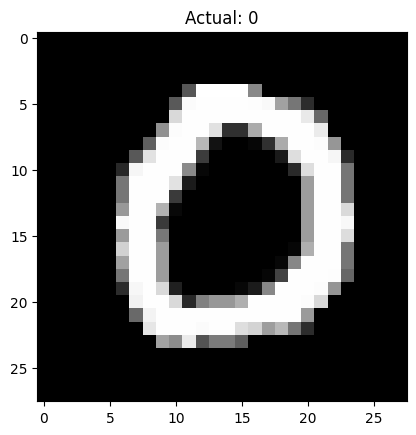

In [36]:
index = 71

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f'Actual: {np.argmax(y_test[index])}')
plt.show()

In [37]:
pred = model.predict(x_test[index].reshape(1, 28, 28, 1))
predicted_digit = np.argmax(pred)
print('Predicted: ', predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted:  0
